# SEACells — kernel archetypal analysis

> Persad et al. *SEACells infers transcriptional and epigenomic cellular
> states from single-cell genomics data.* **Nature Biotechnology** 41,
> 1746–1757 (2023). [doi:10.1038/s41587-023-01716-9](https://doi.org/10.1038/s41587-023-01716-9)

**Algorithm.** Builds an adaptive Gaussian kernel on diffusion components,
then runs *kernel archetypal analysis* to fit ``n_SEACells`` archetypes and a
**soft membership matrix** ``A_`` (cells × archetypes).  Each cell is a sparse
combination of nearby archetypes.

**Capabilities.** ``soft``, ``latent``.

**Strengths.** Mathematically clean (explicit convex objective).  Soft
memberships let you do proper weighted aggregation.  Native support for ATAC.

**Weaknesses.** O(N²) kernel construction; doesn't scale past ~100k cells.
No closed-form out-of-sample projection.  GPU helps but doesn't change the
complexity.

## 1. Setup

In [1]:
# Standard imports + omicverse defaults.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import omicverse as ov
import scvelo as scv      # only used for the demo dataset

ov.plot_set()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.0   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 2. Load and preprocess

In [2]:
# Pancreas scRNA-seq (Bastidas-Ponce et al. 2019). Standard omicverse
# preprocess flow: qc -> preprocess -> scale -> pca -> neighbors -> umap.
adata = scv.datasets.pancreas()
adata = ov.pp.qc(adata,
                 tresh={'mito_perc': 0.20, 'nUMIs': 500, 'detected_genes': 250},
                 mt_startswith='mt-')
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=2000)
adata.layers['lognorm'] = adata.X.copy()        # mcRigor reads this
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=30)
adata.obsm['X_pca'] = adata.obsm['scaled|original|X_pca']
ov.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca')
ov.pp.umap(adata)
print('adata:', adata.shape, 'celltypes:', sorted(adata.obs['clusters'].unique()))

🖥️ Using CPU mode for QC...

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 0 ⚠️               │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 0 ⚠️               │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range (Min - Max)       │
   ├─────────────────────

   ✓ Final filtering: 0 cells, 12,261 genes removed

🔍 Step 4: Doublet Detection
   💡 Running pyscdblfinder (Python port of R scDblFinder)
   🔍 Running scdblfinder detection...


[ScDblFinder] wrote scDblFinder_score + scDblFinder_class — threshold=0.387
   ✓ scDblFinder completed: 66 doublets removed (1.8%)



╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 16.8177s                                                │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ n_counts (float)                                     │
│           │ ✚ n_genes (int)                                        │
│           │ ✚ n_genes_by_counts (int)                              │
│    

    After filtration, 15737/15737 genes are kept.
    Among 15737 genes, 15736 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson


...


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.7865s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3630x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3630, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (1.62s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 1.6312s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3630x30)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction

   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 3,630 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 8.7809s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
🔍 [2026-05-19 17:33:10] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...

🔍 UMAP Dimensionality Reduction:
   Mode: cpu
   Method: umap
   Components: 2
   Min distan


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 3,630 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.739s                                                  │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': 0.5830300199950147, 'b': 1.334166993228519}│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
adata: (3630, 2000)

## 3. Fit SEACells

Build the kernel on `X_pca` and fit 100 archetypes.  `device='cuda'` would
move Franke–Wolfe onto the GPU (requires `cupy`); the default CPU path is
plenty fast on this 3.6 k-cell dataset.

In [3]:
mc = ov.single.MetaCell(
    adata.copy(), method='seacells', n_metacells=100,
    use_rep='X_pca', device='cpu', random_state=0,
).fit()
print(f'fit done: {mc.method}, runtime={mc._fit_result.runtime_s:.2f} s')

Welcome to SEACells!


  0%|          | 0/3630 [00:00<?, ?it/s]

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/3630 [00:00<?, ?it/s]

  0%|          | 0/3630 [00:00<?, ?it/s]

Building kernel on X_pca


  0%|                                                                                                                      | 0/17 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 495.28it/s]

fit done: seacells, runtime=16.83 s


## 4. AnnData schema after fit

Every backend writes the same fields into ``adata`` — that's what lets the
downstream helpers below work without branching on the backend.

In [4]:
# Inspect what the fit wrote into adata via the unified schema.
print(f'method      : {mc.method}')
print(f'capabilities: {sorted(mc.capabilities)}')
print(f'n_metacells : {np.unique(mc._fit_result.assignments).size}')
print(f'runtime     : {mc._fit_result.runtime_s:.3f} s')
print(f'uns         : {dict(mc.adata.uns["metacell"])}')

method      : seacells
capabilities: ['latent', 'soft']
n_metacells : 100
runtime     : 16.831 s
uns         : {'method': 'seacells', 'n_metacells': 100, 'n_iter': 11, 'converged': True, 'runtime_s': 16.831217527389526, 'random_state': 0, 'capabilities': ['latent', 'soft']}


## 5. Aggregate to a metacell AnnData

`predicted(method='hard', layer='counts', summary='sum')` returns a
metacell × gene AnnData with raw count totals preserved — the format that
downstream tools (SCENIC, CellPhoneDB, pseudobulk DE) actually want.

In [5]:
ad_mc = mc.predicted(method='hard', layer='counts', summary='sum',
                     celltype_label='clusters')
print(f'metacell AnnData: {ad_mc.shape}')
print(f'mean cells/metacell: {ad_mc.obs["n_cells"].mean():.1f}')
ad_mc.obs.head()

metacell AnnData: (100, 2000)
mean cells/metacell: 36.3


,n_cells,clusters,clusters_purity
mc-0,26,Ngn3 high EP,0.692308
mc-1,14,Epsilon,1.000000
mc-2,35,Beta,1.000000
mc-3,63,Ngn3 low EP,0.555556
mc-4,27,Ductal,0.814815


## 6. Benchmarking metrics (purity / separation / compactness)

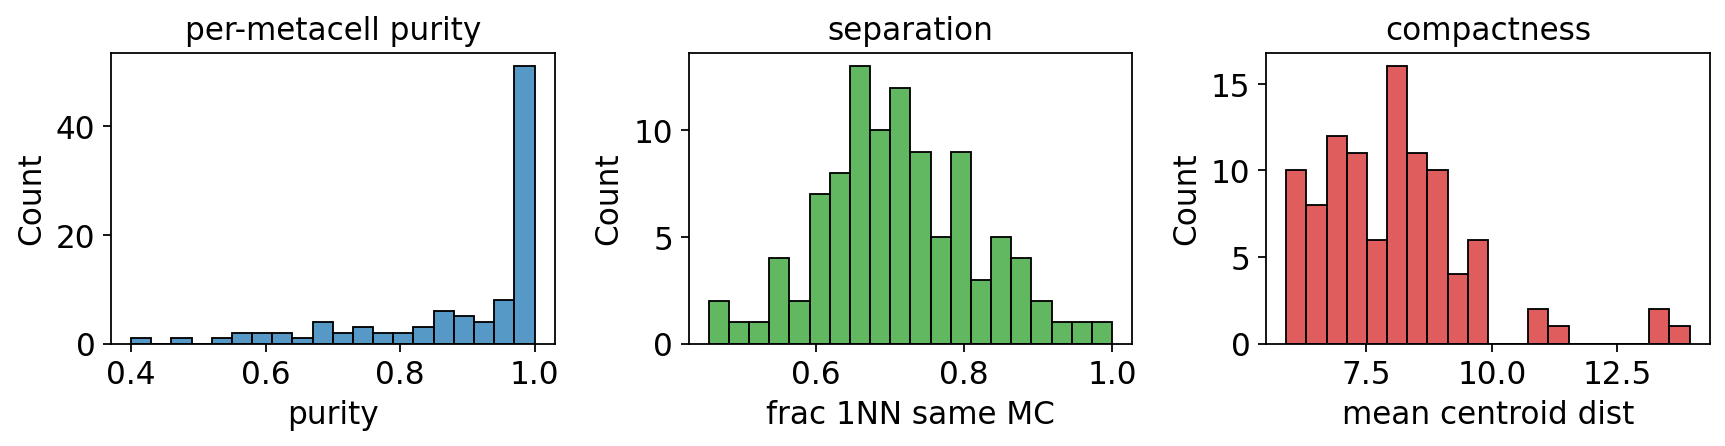

In [6]:
# Compute purity / separation / compactness AND show the 3-panel histogram
# in one call (ov.pl.metacell_metrics returns the per-metacell tables too).
purity, separation, compactness = ov.pl.metacell_metrics(
    mc, label_key='clusters', use_rep='X_pca',
)

## 7. mcRigor: statistical validation

For each metacell, mcRigor permutes the (cells × genes) submatrix in two
ways and asks: *is the observed gene–gene covariance bigger than the null
distribution at this metacell's size?*  Metacells whose `mcDiv` exceeds the
size-stratified threshold are flagged as `'dubious'`.

In [7]:
# mcRigor's double-permutation null. dubious_rate = fraction of cells in
# heterogeneous metacells; rigor_score = 1 - 0.5*(dubious_rate + zero_rate).
rep = mc.check_rigor(layer_lognorm='lognorm', n_rep=20,
                     feature_use=1000, random_state=0)
print(f'rigor_score : {rep.score:.3f}')
print(f'dubious_rate: {rep.dubious_rate:.3f}')
print(f'zero_rate   : {rep.zero_rate:.3f}')
print(f'# metacells : {rep.n_metacells}')

rigor_score : 0.645
dubious_rate: 0.466
zero_rate   : 0.243
# metacells : 100


### 7.1 Per-metacell `mcDiv` vs size

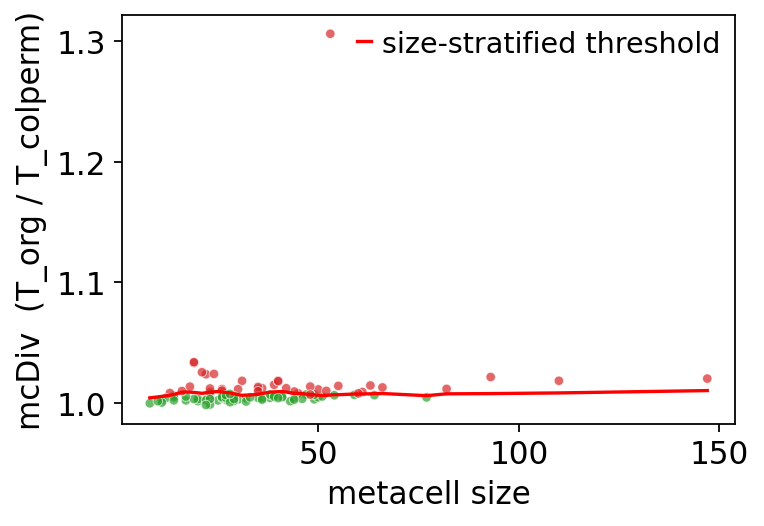

<Axes: xlabel='metacell size', ylabel='mcDiv  (T_org / T_colperm)'>

In [8]:
# mcDiv vs metacell size, overlaid with size-stratified threshold.
ov.pl.rigor_scatter(rep)

## 8. UMAP with metacell centroids

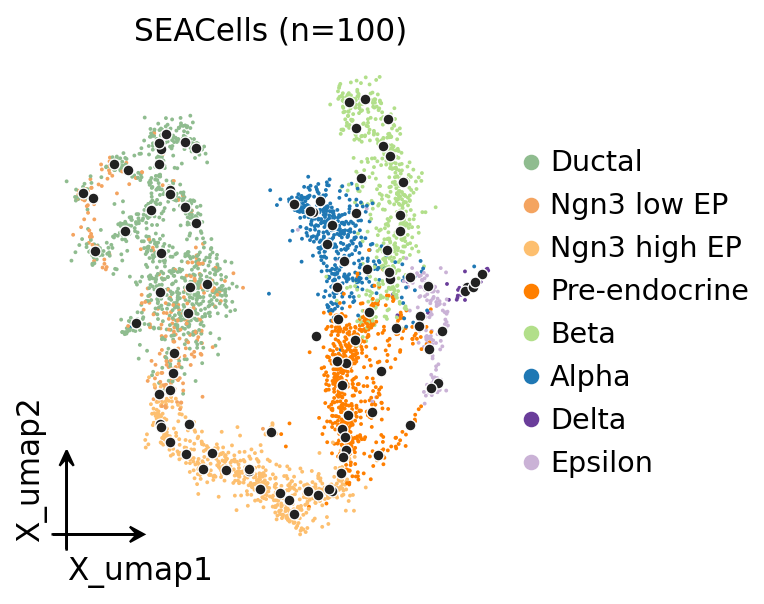

In [9]:
# UMAP coloured by celltype with metacell centroids overlaid in dark grey.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
ov.pl.embedding(mc.adata, basis='X_umap', color='clusters', ax=ax, show=False,
                frameon='small', title='SEACells (n=100)', size=12)
labels = mc._fit_result.assignments
pts = np.array([mc.adata.obsm['X_umap'][labels == u].mean(axis=0)
                for u in np.unique(labels)])
ax.scatter(pts[:, 0], pts[:, 1], s=24, c='#222',
           edgecolors='white', linewidths=0.6, zorder=5)
plt.tight_layout(); plt.show()

## 9. Per-celltype purity boxplot

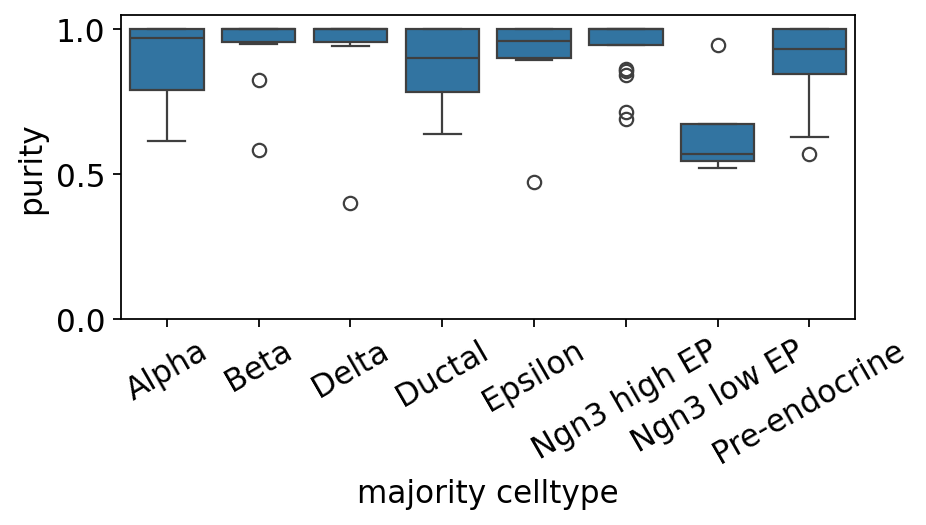

<Axes: xlabel='majority celltype', ylabel='purity'>

In [10]:
# Per-celltype boxplot of metacell purity.
ov.pl.metacell_purity_box(mc, label_key='clusters')

## 10. Metacell-level UMAP

A common downstream use of metacells is to treat them as a much smaller
"atlas" of pseudo-cells and re-run the standard omicverse preprocess → PCA
→ UMAP loop on them.  Cell-type signal should survive.

🔍 [2026-05-19 17:33:58] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 2000/2000 genes are kept.
    Among 2000 genes, 2000 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 100 cells × 2,000 genes
   ✓ Runtime: 0.00s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 2,000 total (100.0%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_ra

   🔧 PCA solver used: covariance_eigh
    finished✅ (1.15s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 1.1501s                                                 │
│  Shape:    100 x 2,000 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 100x30)                                │
│           │ ✚ scaled|original|X_pca (array, 100x30)                │
│         

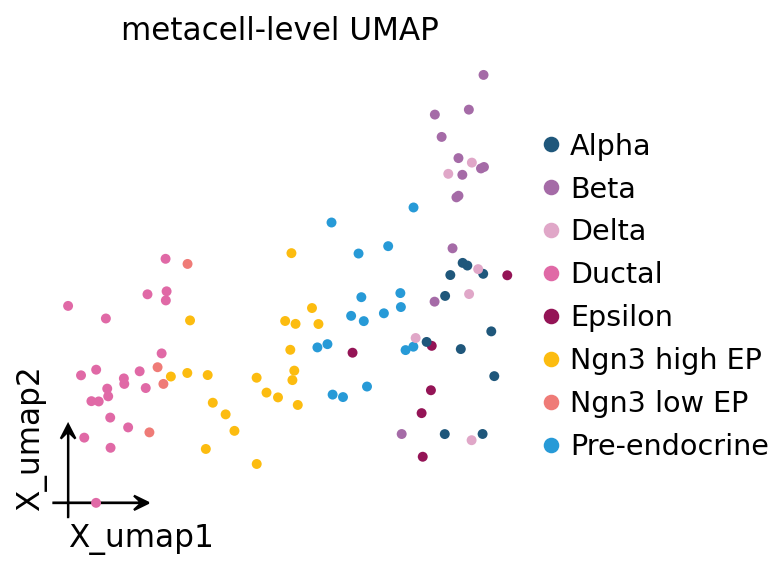

In [11]:
# Treat the metacell AnnData as a smaller dataset and run the standard
# omicverse preprocess -> pca -> neighbors -> umap loop on it.
ad_mc = ov.pp.preprocess(ad_mc, mode='shiftlog|pearson',
                          n_HVGs=min(2000, ad_mc.n_vars))
ad_mc = ad_mc[:, ad_mc.var.highly_variable_features]
ov.pp.scale(ad_mc)
ov.pp.pca(ad_mc, layer='scaled', n_pcs=min(30, ad_mc.n_obs - 1))
ad_mc.obsm['X_pca'] = ad_mc.obsm['scaled|original|X_pca']
ov.pp.neighbors(ad_mc, n_neighbors=min(15, ad_mc.n_obs - 1), use_rep='X_pca')
ov.pp.umap(ad_mc)
ov.pl.embedding(ad_mc, basis='X_umap', color='clusters',
                frameon='small', title='metacell-level UMAP', size=80)

## 11. Top markers per celltype on the metacell AnnData

In [12]:
# Find top markers per celltype on the metacell AnnData (omicverse helper —
# drops the categories with <2 metacells automatically and reports cell-type
# fractions ``pts`` along with the gene names).
counts = ad_mc.obs['clusters'].value_counts()
keep = counts[counts >= 2].index.tolist()
ad_mc_for_de = ad_mc[ad_mc.obs['clusters'].isin(keep)].copy()
ad_mc_for_de.obs['clusters'] = ad_mc_for_de.obs['clusters'].astype('category')

ov.single.find_markers(ad_mc_for_de, groupby='clusters', method='wilcoxon',
                       key_added='rank_genes_groups', pts=True, use_gpu=False)
ov.single.get_markers(ad_mc_for_de, n_genes=3, key='rank_genes_groups')

🔍 Finding marker genes | method: wilcoxon | groupby: clusters | n_groups: 8 | n_genes: 50
✅ Done | 8 groups × 50 genes | corr: benjamini-hochberg | stored in adata.uns['rank_genes_groups']


,group,rank,names,scores,logfoldchanges,pvals,pvals_adj,pct_group,pct_rest
0,Alpha,1,Sphkap,5.381498,5.620847,7.386865e-08,2.077214e-05,1.0,0.449438
1,Alpha,2,Smarca1,5.348449,3.378446,8.871137e-08,2.077214e-05,1.0,0.988764
2,Alpha,3,Tmem27,5.337432,6.293408,9.427214e-08,2.077214e-05,1.0,0.808989
3,Beta,1,Gng12,5.796038,4.034294,6.789978e-09,2.672994e-06,1.0,1.000000
4,Beta,2,Papss2,5.785789,5.529241,7.217283e-09,2.672994e-06,1.0,0.609195
5,Beta,3,Sec61b,5.765290,1.695018,8.151753e-09,2.672994e-06,1.0,1.000000
6,Delta,1,Rbp4,4.092979,5.551823,4.258667e-05,9.540831e-03,1.0,1.000000
7,Delta,2,Pyy,4.092979,5.879094,4.258667e-05,9.540831e-03,1.0,1.000000
8,Delta,3,Sst,4.078465,11.871149,4.533409e-05,9.540831e-03,1.0,0.691489
9,Ductal,1,Nudt19,7.139349,3.294932,9.377431e-13,8.161789e-11,1.0,1.000000


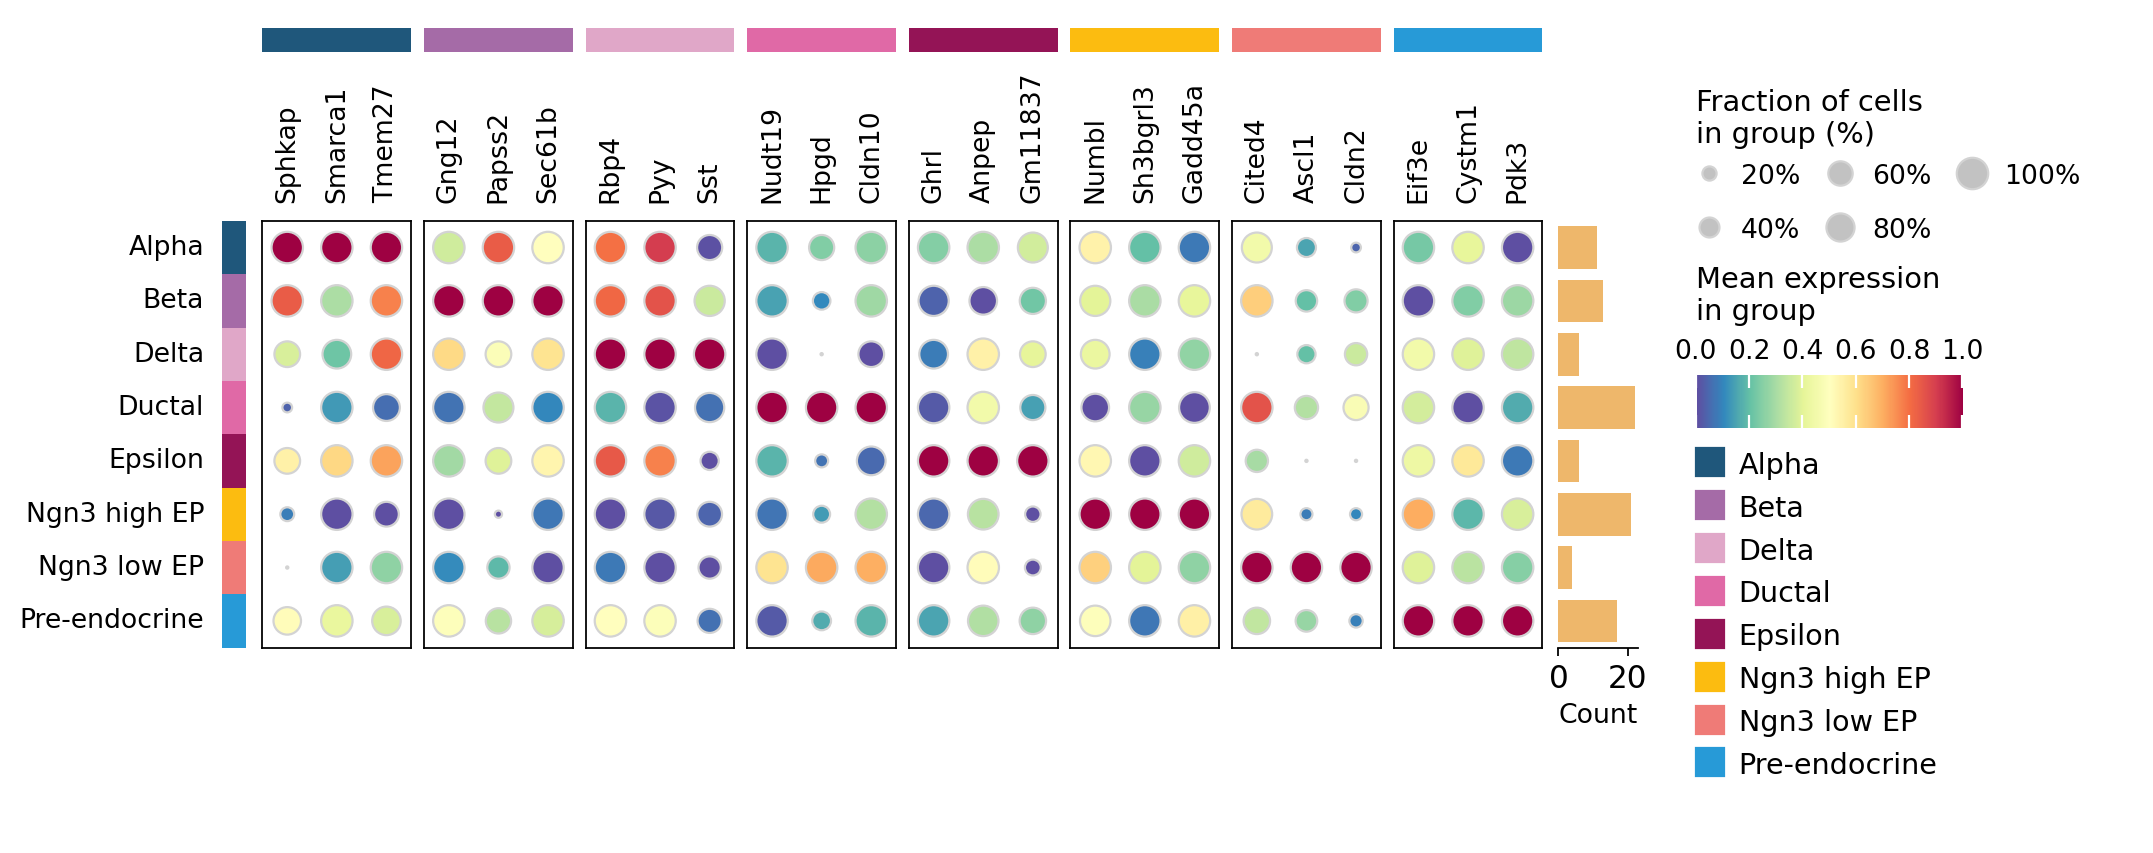

In [13]:
# Dotplot of top markers per metacell-level celltype.
ov.pl.markers_dotplot(ad_mc_for_de, groupby='clusters', n_genes=3,
                      key='rank_genes_groups')

## 12. SEACells-specific: soft membership matrix

`A_` is the per-cell sparse soft-membership over archetypes — what makes
SEACells different from a hard partitioner.  Most cells are explained by
1–3 archetypes; the rest of the row is exactly zero.  This is what enables
weighted aggregation in DE / velocity / cell–cell communication.

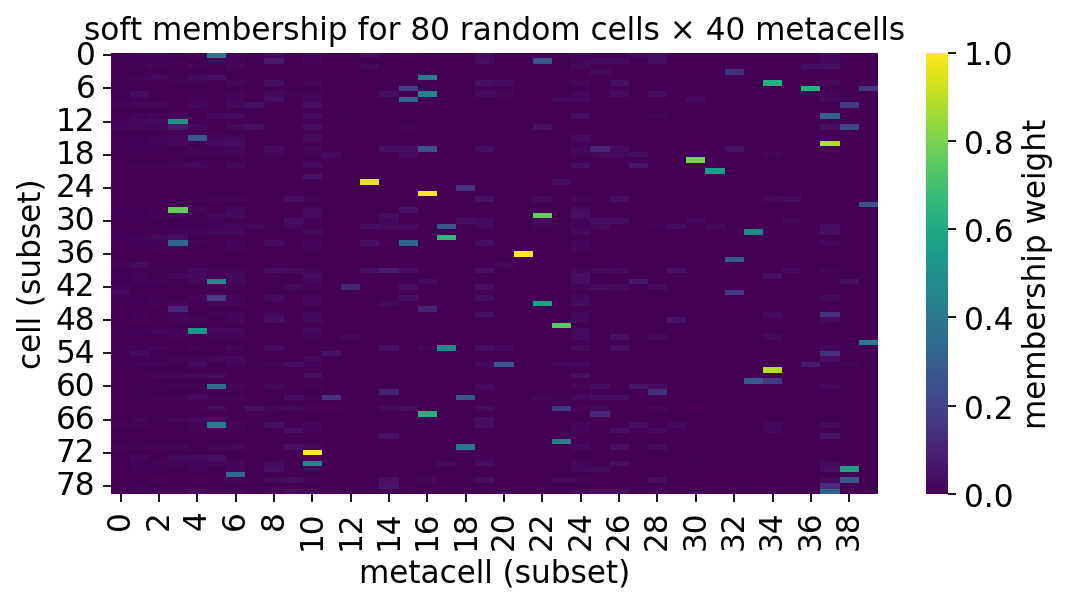

<Axes: title={'center': 'soft membership for 80 random cells × 40 metacells'}, xlabel='metacell (subset)', ylabel='cell (subset)'>

In [14]:
# Heatmap of soft membership for a random subset of cells × metacells.
ov.pl.metacell_soft_heatmap(mc, n_cells=80, n_mc=40, random_state=0)

In [15]:
# Quick stats on how many archetypes each cell touches.
soft = mc.soft_membership().tocsr()
nnz_per_cell = (soft > 0).sum(axis=1).A1
print(f'soft membership shape   : {soft.shape}')
print(f'mean archetypes per cell: {nnz_per_cell.mean():.2f}')
print(f'sparsity                : {1 - soft.nnz / (soft.shape[0]*soft.shape[1]):.4f}')
pd.Series(nnz_per_cell).value_counts().sort_index().head(8)

soft membership shape   : (3630, 100)
mean archetypes per cell: 13.22
sparsity                : 0.8678


1    269
2    343
3    230
4    163
5    129
6     97
7    101
8     82
Name: count, dtype: int64

## 13. Save / load roundtrip

In [16]:
# Save/load roundtrip — every backend supports this.
import tempfile, os
with tempfile.NamedTemporaryFile(suffix='.pkl', delete=False) as f:
    path = f.name
mc.save(path)

mc2 = ov.single.MetaCell(adata.copy(), method='seacells', n_metacells=100,
                          use_rep='X_pca', random_state=0)
mc2.load(path)
print(f'saved+loaded {path}')
os.remove(path)

saved+loaded /tmp/tmprd7xl3wc.pkl


## 14. Takeaways

- SEACells gives you a **soft membership** every other backend (except MetaQ
  via top-k cosine) lacks.  This is what makes weighted-aggregate DE and
  RNA-velocity-on-metacells work.
- O(N²) kernel construction is the bottleneck — on this 3.6 k-cell dataset
  it's fine on CPU; past 100 k cells the `cupy` GPU mode is essential and
  past 1 M cells switch to `metaq` or `mc2`.
- For atlas workflows requiring out-of-sample projection, use `metaq`
  instead.